In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

#El contexto del data set es sobre las estimaciones de taza de pobreza multidimensional por comuna en Chile del año 2015
#Integrantes: Alejandra Guzman - Macarena Lobos Sección 002D
#https://github.com/masolopa/MINERIADEDATOS

In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv("musica_y_salud_mental.csv")

In [ ]:
#Se observa el data frame en bruto
df

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,BPM,Frequency [Classical],Frequency [Country],Frequency [EDM],Frequency [Folk],Frequency [Gospel],Frequency [Hip hop],Frequency [Jazz],Frequency [K pop],Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.00,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.50,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.00,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.50,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.00,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
5,8/27/2022 21:56:50,18.0,Spotify,5.00,Yes,Yes,Yes,Jazz,Yes,Yes,86.0,Rarely,Sometimes,Never,Never,Never,Sometimes,Very frequently,Very frequently,Rarely,Very frequently,Rarely,Very frequently,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,I understand.
6,8/27/2022 22:00:29,18.0,YouTube Music,3.00,Yes,Yes,No,Video game music,Yes,Yes,66.0,Sometimes,Never,Rarely,Sometimes,Rarely,Rarely,Sometimes,Never,Rarely,Rarely,Rarely,Rarely,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,I understand.
7,8/27/2022 22:18:59,21.0,Spotify,1.00,Yes,No,No,K pop,Yes,Yes,95.0,Never,Never,Rarely,Never,Never,Very frequently,Rarely,Very frequently,Never,Sometimes,Never,Sometimes,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve,I understand.
8,8/27/2022 22:33:05,19.0,Spotify,6.00,Yes,No,No,Rock,No,No,94.0,Never,Very frequently,Never,Sometimes,Never,Never,Never,Never,Never,Never,Very frequently,Never,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,Improve,I understand.
9,8/27/2022 22:44:03,18.0,I do not use a streaming service.,1.00,Yes,No,No,R&B,Yes,Yes,155.0,Rarely,Rarely,Rarely,Rarely,Sometimes,Rarely,Rarely,Never,Rarely,Rarely,Never,Sometimes,Sometimes,Rarely,Sometimes,Sometimes,2.0,2.0,5.0,1.0,Improve,I understand.


In [ ]:
#Se consultan los nombres de las columnas del data frame
print("Nombres de columnas actuales:")
print(df.columns.tolist())

Nombres de columnas actuales:
['Timestamp', 'Age', 'Primary streaming service', 'Hours per day', 'While working', 'Instrumentalist', 'Composer', 'Fav genre', 'Exploratory', 'Foreign languages', 'BPM', 'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]', 'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]', 'Anxiety', 'Depression', 'Insomnia', 'OCD', 'Music effects', 'Permissions']


In [ ]:
#Se renombran las columnas del df
df.columns = ['Fecha y hora', 'Edad','App utilizada', 'Horas de escucha por día','¿Escucha música mientras trabaja?', '¿Toca algún instrumento?','¿Compone música?', '¿Cuál es su género favorito de música?', '¿Le gusta explorar nuevos artistas/géneros?', '¿Escucha música en lenguajes que usted no habla?', 'Beats por minuto de su género musical favorito', '¿Qué tan seguido escucha música clasica?', '¿Qué tan seguido escucha country?', '¿Qué tan seguido escucha electrónica?', '¿Qué tan seguido escucha folk?', '¿Qué tan seguido escucha gospel?', '¿Qué tan seguido escucha hip-hop?', '¿Qué tan seguido escucha jazz?', '¿Qué tan seguido escucha k-pop?', '¿Qué tan seguido escucha múica latina?', '¿Qué tan seguido escucha lo-fi?', '¿Qué tan seguido escucha metal?', '¿Qué tan seguido escucha pop?', '¿Qué tan seguido escucha r&b?', '¿Qué tan seguido escucha rap?', '¿Qué tan seguido escucha rock?', '¿Qué tan seguido escucha música de videojuegos?','¿Cuál es su reporte de ansiedad en escala de 1 a 10?', '¿Cuál es su reporte de depresión en escala de 1 a 10?', '¿Cuál es su reporte de insomnio en escala de 1 a 10?', '¿Cuál es su reporte de TOC en escala de 1 a 10?', '¿Cuál es el efecto que produce la música en sus condiciones de salud mental?', 'Permiso para publicar la data' ]
display(df.head())

,Fecha y hora,Edad,App utilizada,Horas de escucha por día,¿Escucha música mientras trabaja?,¿Toca algún instrumento?,¿Compone música?,¿Cuál es su género favorito de música?,¿Le gusta explorar nuevos artistas/géneros?,¿Escucha música en lenguajes que usted no habla?,Beats por minuto de su género musical favorito,¿Qué tan seguido escucha música clasica?,¿Qué tan seguido escucha country?,¿Qué tan seguido escucha electrónica?,¿Qué tan seguido escucha folk?,¿Qué tan seguido escucha gospel?,¿Qué tan seguido escucha hip-hop?,¿Qué tan seguido escucha jazz?,¿Qué tan seguido escucha k-pop?,¿Qué tan seguido escucha múica latina?,¿Qué tan seguido escucha lo-fi?,¿Qué tan seguido escucha metal?,¿Qué tan seguido escucha pop?,¿Qué tan seguido escucha r&b?,¿Qué tan seguido escucha rap?,¿Qué tan seguido escucha rock?,¿Qué tan seguido escucha música de videojuegos?,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?,Permiso para publicar la data
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [ ]:
#Se muestran las primeras 5 filas
df.head()

,Fecha y hora,Edad,App utilizada,Horas de escucha por día,¿Escucha música mientras trabaja?,¿Toca algún instrumento?,¿Compone música?,¿Cuál es su género favorito de música?,¿Le gusta explorar nuevos artistas/géneros?,¿Escucha música en lenguajes que usted no habla?,Beats por minuto de su género musical favorito,¿Qué tan seguido escucha música clasica?,¿Qué tan seguido escucha country?,¿Qué tan seguido escucha electrónica?,¿Qué tan seguido escucha folk?,¿Qué tan seguido escucha gospel?,¿Qué tan seguido escucha hip-hop?,¿Qué tan seguido escucha jazz?,¿Qué tan seguido escucha k-pop?,¿Qué tan seguido escucha múica latina?,¿Qué tan seguido escucha lo-fi?,¿Qué tan seguido escucha metal?,¿Qué tan seguido escucha pop?,¿Qué tan seguido escucha r&b?,¿Qué tan seguido escucha rap?,¿Qué tan seguido escucha rock?,¿Qué tan seguido escucha música de videojuegos?,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?,Permiso para publicar la data
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,156.0,Rarely,Never,Rarely,Never,Never,Sometimes,Never,Very frequently,Very frequently,Rarely,Never,Very frequently,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,119.0,Sometimes,Never,Never,Rarely,Sometimes,Rarely,Very frequently,Rarely,Sometimes,Rarely,Never,Sometimes,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [ ]:
#Se muestran las últimas 5 filas del data frame
df.tail()

,Fecha y hora,Edad,App utilizada,Horas de escucha por día,¿Escucha música mientras trabaja?,¿Toca algún instrumento?,¿Compone música?,¿Cuál es su género favorito de música?,¿Le gusta explorar nuevos artistas/géneros?,¿Escucha música en lenguajes que usted no habla?,Beats por minuto de su género musical favorito,¿Qué tan seguido escucha música clasica?,¿Qué tan seguido escucha country?,¿Qué tan seguido escucha electrónica?,¿Qué tan seguido escucha folk?,¿Qué tan seguido escucha gospel?,¿Qué tan seguido escucha hip-hop?,¿Qué tan seguido escucha jazz?,¿Qué tan seguido escucha k-pop?,¿Qué tan seguido escucha múica latina?,¿Qué tan seguido escucha lo-fi?,¿Qué tan seguido escucha metal?,¿Qué tan seguido escucha pop?,¿Qué tan seguido escucha r&b?,¿Qué tan seguido escucha rap?,¿Qué tan seguido escucha rock?,¿Qué tan seguido escucha música de videojuegos?,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?,Permiso para publicar la data
731,10/30/2022 14:37:28,17.0,Spotify,2.0,Yes,Yes,No,Rock,Yes,Yes,120.0,Very frequently,Rarely,Never,Sometimes,Never,Sometimes,Rarely,Never,Sometimes,Rarely,Rarely,Very frequently,Never,Rarely,Very frequently,Never,7.0,6.0,0.0,9.0,Improve,I understand.
732,11/1/2022 22:26:42,18.0,Spotify,1.0,Yes,Yes,No,Pop,Yes,Yes,160.0,Rarely,Rarely,Never,Never,Never,Never,Rarely,Never,Never,Rarely,Never,Very frequently,Never,Never,Sometimes,Sometimes,3.0,2.0,2.0,5.0,Improve,I understand.
733,11/3/2022 23:24:38,19.0,Other streaming service,6.0,Yes,No,Yes,Rap,Yes,No,120.0,Rarely,Sometimes,Sometimes,Rarely,Rarely,Very frequently,Rarely,Rarely,Rarely,Sometimes,Rarely,Sometimes,Sometimes,Sometimes,Rarely,Rarely,2.0,2.0,2.0,2.0,Improve,I understand.
734,11/4/2022 17:31:47,19.0,Spotify,5.0,Yes,Yes,No,Classical,No,No,170.0,Very frequently,Never,Never,Never,Never,Never,Rarely,Never,Never,Never,Never,Never,Never,Never,Never,Sometimes,2.0,3.0,2.0,1.0,Improve,I understand.
735,11/9/2022 1:55:20,29.0,YouTube Music,2.0,Yes,No,No,Hip hop,Yes,Yes,98.0,Sometimes,Rarely,Very frequently,Sometimes,Rarely,Very frequently,Very frequently,Sometimes,Never,Rarely,Never,Sometimes,Very frequently,Very frequently,Very frequently,Rarely,2.0,2.0,2.0,5.0,Improve,I understand.


In [ ]:
#Se listan las columnas del data frame
df.columns

Index(['Fecha y hora', 'Edad', 'App utilizada', 'Horas de escucha por día',
       '¿Escucha música mientras trabaja?', '¿Toca algún instrumento?',
       '¿Compone música?', '¿Cuál es su género favorito de música?',
       '¿Le gusta explorar nuevos artistas/géneros?',
       '¿Escucha música en lenguajes que usted no habla?',
       'Beats por minuto de su género musical favorito',
       '¿Qué tan seguido escucha música clasica?',
       '¿Qué tan seguido escucha country?',
       '¿Qué tan seguido escucha electrónica?',
       '¿Qué tan seguido escucha folk?', '¿Qué tan seguido escucha gospel?',
       '¿Qué tan seguido escucha hip-hop?', '¿Qué tan seguido escucha jazz?',
       '¿Qué tan seguido escucha k-pop?',
       '¿Qué tan seguido escucha múica latina?',
       '¿Qué tan seguido escucha lo-fi?', '¿Qué tan seguido escucha metal?',
       '¿Qué tan seguido escucha pop?', '¿Qué tan seguido escucha r&b?',
       '¿Qué tan seguido escucha rap?', '¿Qué tan seguido escucha rock?',


In [ ]:
df.isna().sum() #Se cuentan el total de los valores faltantes por cada columna, se visualiza que los datos faltantes en la columna de beats por minuto son bastantes pero la columna no es tan relevante para el estudio, los demás valores nulos encontrados, son la menor cantidad en 7 filas de las 33

Fecha y hora                                                                      0
Edad                                                                              1
App utilizada                                                                     1
Horas de escucha por día                                                          0
¿Escucha música mientras trabaja?                                                 3
¿Toca algún instrumento?                                                          4
¿Compone música?                                                                  1
¿Cuál es su género favorito de música?                                            0
¿Le gusta explorar nuevos artistas/géneros?                                       0
¿Escucha música en lenguajes que usted no habla?                                  4
Beats por minuto de su género musical favorito                                  107
¿Qué tan seguido escucha música clasica?                                    

In [ ]:
df.info() #Muestra en detalle cuantas columnas hay, sus nombres, también muestra que hay 3entre 629 y 736 filas de datos

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                                                                        Non-Null Count  Dtype  
---  ------                                                                        --------------  -----  
 0   Fecha y hora                                                                  736 non-null    str    
 1   Edad                                                                          735 non-null    float64
 2   App utilizada                                                                 735 non-null    str    
 3   Horas de escucha por día                                                      736 non-null    float64
 4   ¿Escucha música mientras trabaja?                                             733 non-null    str    
 5   ¿Toca algún instrumento?                                                      732 non-null    str    
 6   ¿Compone música?                             

In [ ]:
df.shape #Muestra filas y luego columnas totales

(736, 33)

In [ ]:
df.dtypes #Muestra el tipo de dato de cada columna

Fecha y hora                                                                        str
Edad                                                                            float64
App utilizada                                                                       str
Horas de escucha por día                                                        float64
¿Escucha música mientras trabaja?                                                   str
¿Toca algún instrumento?                                                            str
¿Compone música?                                                                    str
¿Cuál es su género favorito de música?                                              str
¿Le gusta explorar nuevos artistas/géneros?                                         str
¿Escucha música en lenguajes que usted no habla?                                    str
Beats por minuto de su género musical favorito                                  float64
¿Qué tan seguido escucha música 

In [ ]:
df = df.dropna() #Se preparan los datos para eliminar variables irrelevantes y datos faltantes con la técnica más agresiva

In [ ]:
df.isnull().sum() #confirmamos la eliminacion del nulo

Fecha y hora                                                                    0
Edad                                                                            0
App utilizada                                                                   0
Horas de escucha por día                                                        0
¿Escucha música mientras trabaja?                                               0
¿Toca algún instrumento?                                                        0
¿Compone música?                                                                0
¿Cuál es su género favorito de música?                                          0
¿Le gusta explorar nuevos artistas/géneros?                                     0
¿Escucha música en lenguajes que usted no habla?                                0
Beats por minuto de su género musical favorito                                  0
¿Qué tan seguido escucha música clasica?                                        0
¿Qué tan seguido

In [ ]:
#Agrupación de las columnas por tipos de datos

tipos = df.columns.to_series().groupby(df.dtypes, sort=False).groups

#Conociendo la lista de columnas categoricas

ctext = df.select_dtypes(include=['object', 'string']).columns.tolist()
cnum = df.select_dtypes(exclude=['object', 'string']).columns.tolist() #Cantidad de columnas con datos categóricos

In [ ]:
#Conociendo la lista de columnas numéricas

columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)


7

In [ ]:
#Se comprueban los nulos del df
df.isnull().any().any()

np.False_

In [ ]:
df.describe() #Estadistica descriptiva sobre variables numericas, identificó 7 columnas numéricas
              # y que el rango de edad entre quienes escuchan música es de 10 a 89 años

,Edad,Horas de escucha por día,Beats por minuto de su género musical favorito,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?
count,616.000000,616.000000,6.160000e+02,616.000000,616.000000,616.000000,616.000000
mean,24.792208,3.702435,1.623500e+06,5.883929,4.894481,3.801136,2.659091
std,11.658515,3.071961,4.029114e+07,2.758269,2.998005,3.111972,2.857285
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,27.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


In [ ]:
pip install category_encoders #Se instalan las librerias para poder realizar encoders para convertir variables categóricas o de texto en valores numéricos

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#Se': Expected package name at the start of dependency specifier
    #Se
    ^


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [ ]:
cant_cat_col_app_df = df['App utilizada'].value_counts()#nos mostrará la cantidad de personas por cada app
print(cant_cat_col_app_df)

# Imprimimos la cantidad total de apps disponibles para escuchar música
print(f"cantidad de aplicaciones para escuchar música: {cant_cat_col_app_df.count()}")

App utilizada
Spotify                              396
YouTube Music                         73
I do not use a streaming service.     56
Apple Music                           42
Other streaming service               40
Pandora                                9
Name: count, dtype: int64
cantidad de aplicaciones para escuchar música: 6


In [ ]:
cant_cat_col_genero_df = df['¿Cuál es su género favorito de música?'].value_counts()#nos mostrará la cantidad de personas por cada género musical
print(cant_cat_col_genero_df)

# Imprimimos la cantidad total de categorias unicas
print(f"cantidad de géneros músicales: {cant_cat_col_genero_df.count()}")

¿Cuál es su género favorito de música?
Rock                149
Pop                  97
Metal                77
Classical            38
Video game music     36
EDM                  36
Hip hop              32
R&B                  30
Folk                 25
K pop                21
Country              20
Rap                  20
Jazz                 19
Lofi                 10
Gospel                4
Latin                 2
Name: count, dtype: int64
cantidad de géneros músicales: 16


In [ ]:
ohe = OneHotEncoder(sparse_output=False)
sm_encoded = ohe.fit_transform(df[['¿Cuál es el efecto que produce la música en sus condiciones de salud mental?']])

#Convertimos el resultado en un DataFrame con nombres de columnas claros
sm_df = pd.DataFrame(
    sm_encoded,
    columns=ohe.get_feature_names_out(['¿Cuál es el efecto que produce la música en sus condiciones de salud mental?']),
    index=df.index)

In [ ]:
# 3. Binary Encoding para 'App utilizada' usando Category Encoders
# Este encoder es ideal para columnas con alta cardinalidad como las comunas
be = ce.BinaryEncoder(cols=['App utilizada'])
df_binary = be.fit_transform(df['App utilizada'])

# 4. Concatenar todo y eliminar las columnas originales
# Unimos el dataframe original (App utilizada y ¿Cuál es el efecto que produce la música en sus condiciones de salud mental? ) con las nuevas columnas
df_final = pd.concat([df.drop(columns=['App utilizada', '¿Cuál es el efecto que produce la música en sus condiciones de salud mental?']), sm_df, df_binary], axis=1)

# 5. Ver los cambios
print(df_final.head())
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")

         Fecha y hora  Edad  Horas de escucha por día  \
2  8/27/2022 21:28:18  18.0                       4.0   
3  8/27/2022 21:40:40  61.0                       2.5   
4  8/27/2022 21:54:47  18.0                       4.0   
5  8/27/2022 21:56:50  18.0                       5.0   
6  8/27/2022 22:00:29  18.0                       3.0   

  ¿Escucha música mientras trabaja? ¿Toca algún instrumento? ¿Compone música?  \
2                                No                       No               No   
3                               Yes                       No              Yes   
4                               Yes                       No               No   
5                               Yes                      Yes              Yes   
6                               Yes                      Yes               No   

  ¿Cuál es su género favorito de música?  \
2                       Video game music   
3                                   Jazz   
4                                    R

In [ ]:
# Muestra las primeras 100 filas del DataFrame codificado (variables transformadas numéricamente)
df_final.head(100)

,Fecha y hora,Edad,Horas de escucha por día,¿Escucha música mientras trabaja?,¿Toca algún instrumento?,¿Compone música?,¿Cuál es su género favorito de música?,¿Le gusta explorar nuevos artistas/géneros?,¿Escucha música en lenguajes que usted no habla?,Beats por minuto de su género musical favorito,¿Qué tan seguido escucha música clasica?,¿Qué tan seguido escucha country?,¿Qué tan seguido escucha electrónica?,¿Qué tan seguido escucha folk?,¿Qué tan seguido escucha gospel?,¿Qué tan seguido escucha hip-hop?,¿Qué tan seguido escucha jazz?,¿Qué tan seguido escucha k-pop?,¿Qué tan seguido escucha múica latina?,¿Qué tan seguido escucha lo-fi?,¿Qué tan seguido escucha metal?,¿Qué tan seguido escucha pop?,¿Qué tan seguido escucha r&b?,¿Qué tan seguido escucha rap?,¿Qué tan seguido escucha rock?,¿Qué tan seguido escucha música de videojuegos?,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,Permiso para publicar la data,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?_Improve,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?_No effect,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?_Worsen,App utilizada_0,App utilizada_1,App utilizada_2
2,8/27/2022 21:28:18,18.0,4.00,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,I understand.,0.0,1.0,0.0,0,0,1
3,8/27/2022 21:40:40,61.0,2.50,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,I understand.,1.0,0.0,0.0,0,1,0
4,8/27/2022 21:54:47,18.0,4.00,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,I understand.,1.0,0.0,0.0,0,0,1
5,8/27/2022 21:56:50,18.0,5.00,Yes,Yes,Yes,Jazz,Yes,Yes,86.0,Rarely,Sometimes,Never,Never,Never,Sometimes,Very frequently,Very frequently,Rarely,Very frequently,Rarely,Very frequently,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,I understand.,1.0,0.0,0.0,0,0,1
6,8/27/2022 22:00:29,18.0,3.00,Yes,Yes,No,Video game music,Yes,Yes,66.0,Sometimes,Never,Rarely,Sometimes,Rarely,Rarely,Sometimes,Never,Rarely,Rarely,Rarely,Rarely,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,I understand.,1.0,0.0,0.0,0,1,0
7,8/27/2022 22:18:59,21.0,1.00,Yes,No,No,K pop,Yes,Yes,95.0,Never,Never,Rarely,Never,Never,Very frequently,Rarely,Very frequently,Never,Sometimes,Never,Sometimes,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,I understand.,1.0,0.0,0.0,0,0,1
8,8/27/2022 22:33:05,19.0,6.00,Yes,No,No,Rock,No,No,94.0,Never,Very frequently,Never,Sometimes,Never,Never,Never,Never,Never,Never,Very frequently,Never,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,I understand.,1.0,0.0,0.0,0,0,1
9,8/27/2022 22:44:03,18.0,1.00,Yes,No,No,R&B,Yes,Yes,155.0,Rarely,Rarely,Rarely,Rarely,Sometimes,Rarely,Rarely,Never,Rarely,Rarely,Never,Sometimes,Sometimes,Rarely,Sometimes,Sometimes,2.0,2.0,5.0,1.0,I understand.,1.0,0.0,0.0,0,1,1
11,8/27/2022 23:00:32,19.0,8.00,Yes,No,No,EDM,Yes,No,125.0,Rarely,Never,Very frequently,Never,Never,Sometimes,Rarely,Rarely,Rarely,Rarely,Never,Rarely,Rarely,Sometimes,Rarely,Rarely,1.0,0.0,0.0,1.0,I understand.,1.0,0.0,0.0,0,1,0
13,8/27/2022 23:12:03,19.0,2.00,Yes,No,No,Country,Yes,No,88.0,Never,Very frequently,Rarely,Sometimes,Never,Sometimes,Never,Never,Never,Rarely,Never,Rarely,Never,Very frequently,Never,Never,2.0,1.0,2.0,0.0,I understand.,1.0,0.0,0.0,0,0,1


In [ ]:
# Estadísticas descriptivas del dataframe codificado (media, std, min, max, etc.)
df_final.describe()

,Edad,Horas de escucha por día,Beats por minuto de su género musical favorito,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?_Improve,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?_No effect,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?_Worsen,App utilizada_0,App utilizada_1,App utilizada_2
count,616.000000,616.000000,6.160000e+02,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000
mean,24.792208,3.702435,1.623500e+06,5.883929,4.894481,3.801136,2.659091,0.754870,0.220779,0.024351,0.147727,0.224026,0.798701
std,11.658515,3.071961,4.029114e+07,2.758269,2.998005,3.111972,2.857285,0.430514,0.415109,0.154261,0.355118,0.417278,0.401297
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,27.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


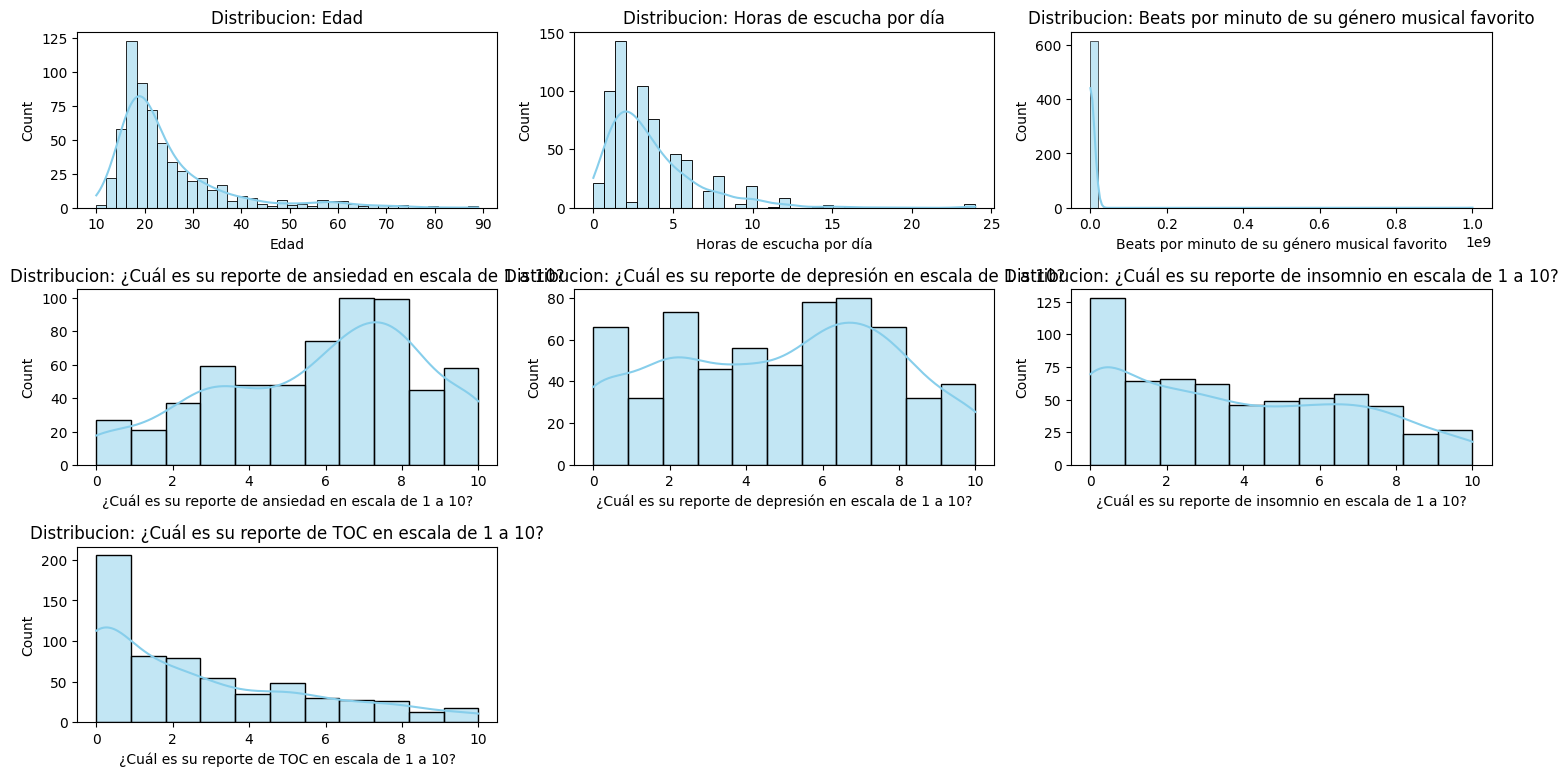

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Lista de columnas numericas originales (sin las codificadas)
cols_numericas = [
    'Edad', 'Horas de escucha por día',
    'Beats por minuto de su género musical favorito', '¿Cuál es su reporte de ansiedad en escala de 1 a 10?', '¿Cuál es su reporte de depresión en escala de 1 a 10?', '¿Cuál es su reporte de insomnio en escala de 1 a 10?',
    '¿Cuál es su reporte de TOC en escala de 1 a 10?'
]

# Configuracion de graficos
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)
    # Histograma con curva de densidad
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribucion: {col}')

plt.tight_layout()
plt.show()

In [ ]:
ascn_order= np.sort(df["Edad"].unique())  #Aquí ordena la Edad en orden ascendente
print(ascn_order)

[10. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28.
 29. 30. 31. 32. 33. 34. 35. 36. 37. 38. 39. 40. 41. 42. 43. 44. 46. 48.
 49. 50. 51. 53. 55. 56. 57. 58. 59. 60. 61. 63. 64. 65. 67. 68. 69. 70.
 72. 73. 74. 80. 89.]


In [ ]:
df["Beats por minuto de su género musical favorito"].value_counts()#Aquí me muestra las cantidades de personas por región que han sido consideradas para la evaluación

Beats por minuto de su género musical favorito
120.0          45
140.0          24
150.0          18
110.0          16
105.0          14
130.0          13
136.0          11
90.0           11
128.0          11
100.0          11
80.0           10
160.0          10
180.0          10
95.0            9
118.0           9
115.0           9
126.0           8
85.0            8
174.0           8
113.0           8
112.0           8
132.0           7
125.0           7
108.0           7
93.0            7
200.0           7
122.0           7
92.0            7
148.0           6
103.0           6
156.0           6
171.0           6
119.0           6
97.0            6
135.0           6
84.0            5
107.0           5
155.0           5
89.0            5
147.0           5
77.0            5
91.0            5
170.0           5
109.0           5
121.0           5
134.0           5
98.0            5
129.0           5
72.0            5
114.0           5
86.0            4
94.0            4
99.0            4

In [ ]:
df['¿Cuál es su género favorito de música?'].value_counts() #Aquí me muestra las cantidades de personas por región que han sido consideradas para la evaluación

¿Cuál es su género favorito de música?
Rock                149
Pop                  97
Metal                77
Classical            38
Video game music     36
EDM                  36
Hip hop              32
R&B                  30
Folk                 25
K pop                21
Country              20
Rap                  20
Jazz                 19
Lofi                 10
Gospel                4
Latin                 2
Name: count, dtype: int64

In [ ]:
# Convertir columnas potencialmente numéricas de df a tipo numérico
num_cols_df = [
    'Edad',
    'Horas de escucha por día',
    'Beats por minuto de su género musical favorito',
    '¿Cuál es su reporte de ansiedad en escala de 1 a 10?',
    '¿Cuál es su reporte de depresión en escala de 1 a 10?',
    '¿Cuál es su reporte de insomnio en escala de 1 a 10?',
    '¿Cuál es su reporte de TOC en escala de 1 a 10?'
]

for col in num_cols_df:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# Agrupación de columnas por tipos de datos para df
ctext_df = df.select_dtypes(include=['object', 'string']).columns.tolist()
cnum_df = df.select_dtypes(exclude=['object', 'string']).columns.tolist()

print(f"Columnas categóricas en df: {len(ctext_df)}")
print(f"Columnas numéricas en df: {len(cnum_df)}")

Columnas categóricas en df: 26
Columnas numéricas en df: 7


In [ ]:
# Completando valores faltantes datos cuantitativos para df
for columna in cnum_df:
  mean = df[columna].mean()
  df[columna] = df[columna].fillna(mean)

In [ ]:
# Completando valores faltantes datos categóricos para df
for columna in ctext_df:
  mode = df[columna].mode()[0]
  df[columna] = df[columna].fillna(mode)

In [ ]:
print("Nulos en df después de la limpieza:")
print(df.isna().sum())

Nulos en df después de la limpieza:
Fecha y hora                                                                    0
Edad                                                                            0
App utilizada                                                                   0
Horas de escucha por día                                                        0
¿Escucha música mientras trabaja?                                               0
¿Toca algún instrumento?                                                        0
¿Compone música?                                                                0
¿Cuál es su género favorito de música?                                          0
¿Le gusta explorar nuevos artistas/géneros?                                     0
¿Escucha música en lenguajes que usted no habla?                                0
Beats por minuto de su género musical favorito                                  0
¿Qué tan seguido escucha música clasica?                      

In [ ]:
# Las columnas numéricas ya se llenaron con la media en una celda anterior (40829e7c).
# Estos pasos son redundantes y pueden causar corrupción en el DataFrame.
# media = df['Número de personas en situación de pobreza por ingresos'].mean()
# moda = df['Número de personas en situación de pobreza por ingresos'].mode()
# df['Número de personas en situación de pobreza por ingresos'] = df['Número de personas en situación de pobreza por ingresos'].fillna(moda)
# Para todas las columnas numéricas
columnas_numericas = cnum_df
for columna in columnas_numericas:
    # Se aseguran que no queden nulos, aunque ya deberían haber sido tratados
    df[columna] = df[columna].fillna(df[columna].mean())

In [ ]:
# Verifica si quedan valores nulos en todo el DataFrame (devuelve True/False)
df.isnull().any().any()

np.False_

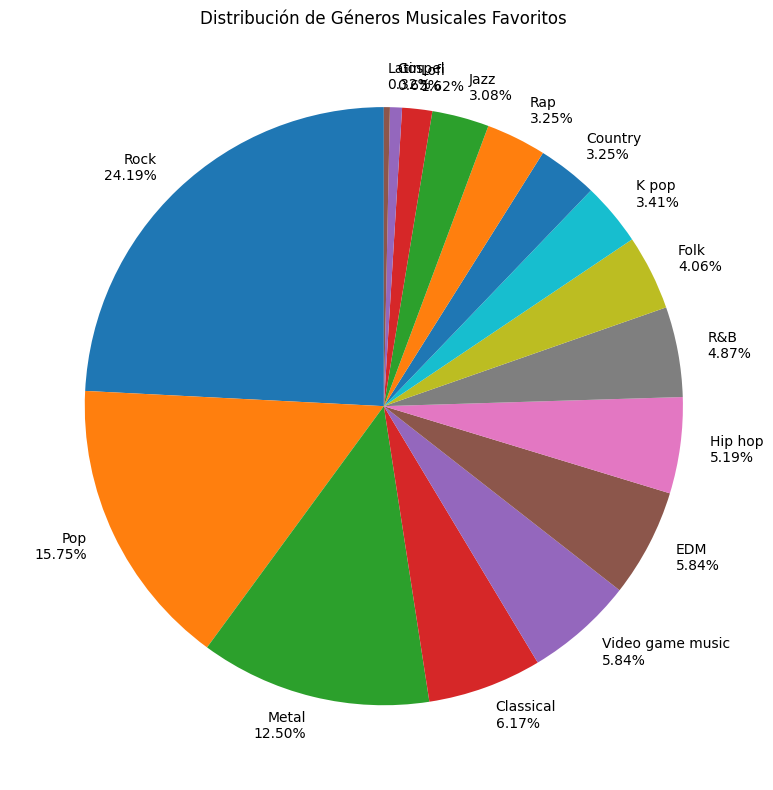

In [ ]:
# Análisis de la distribución de géneros musicales favoritos
genero_counts = df['¿Cuál es su género favorito de música?'].value_counts()

# Creando las leyendas del gráfico con porcentajes
labels = [f'{name}\n{percentage:.2f}%' for name, percentage in zip(genero_counts.index, (genero_counts / genero_counts.sum() * 100))]

plt.figure(figsize=(12, 8))
plt.pie(genero_counts, labels=labels, startangle=90)
plt.title('Distribución de Géneros Musicales Favoritos')
plt.tight_layout()
plt.show()

Aplicaciones utilizadas:
App utilizada
Spotify                              396
YouTube Music                         73
I do not use a streaming service.     56
Apple Music                           42
Other streaming service               40
Pandora                                9
Name: count, dtype: int64


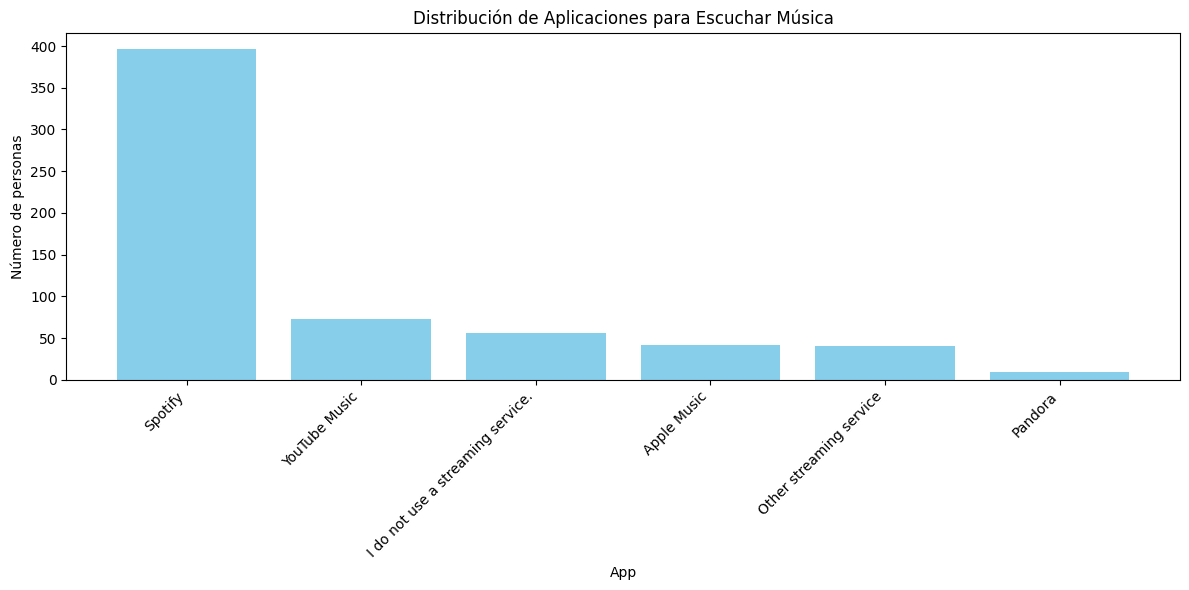

In [ ]:
# Distribución de apps utilizadas para escuchar música
app_count = df['App utilizada'].value_counts()
print("Aplicaciones utilizadas:")
print(app_count)

# Creando el gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(range(len(app_count)), app_count.values, color='skyblue')
plt.xlabel('App')
plt.ylabel('Número de personas')
plt.title('Distribución de Aplicaciones para Escuchar Música')
plt.xticks(range(len(app_count)), app_count.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

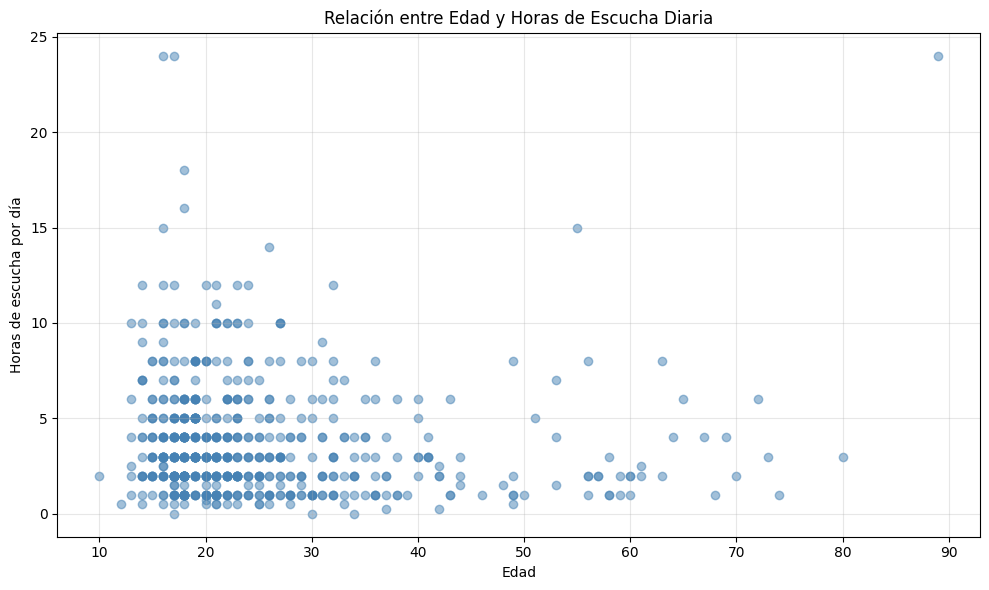

Correlación entre edad y horas de escucha: -0.0449


In [ ]:
# Relación entre edad y horas de escucha diaria
plt.figure(figsize=(10, 6))
plt.scatter(df['Edad'], df['Horas de escucha por día'], alpha=0.5, color='steelblue')
plt.xlabel('Edad')
plt.ylabel('Horas de escucha por día')
plt.title('Relación entre Edad y Horas de Escucha Diaria')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular correlación
corr_edad_horas = df['Edad'].corr(df['Horas de escucha por día'])
print(f"Correlación entre edad y horas de escucha: {corr_edad_horas:.4f}")

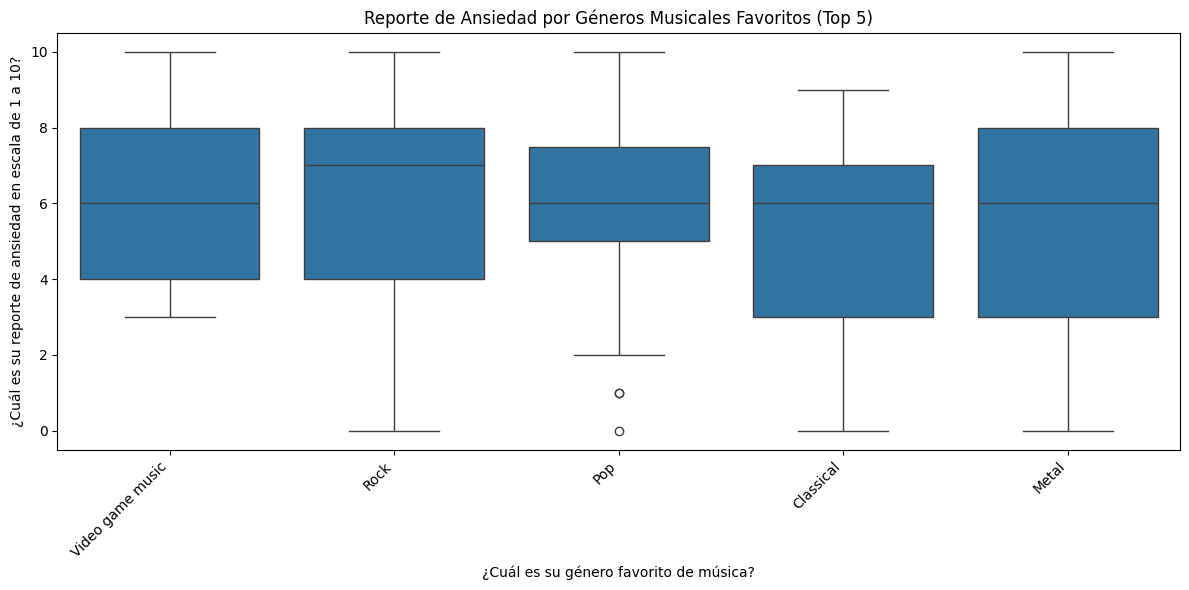

In [ ]:
# Comparación de reporte de salud mental por género musical favorito
plt.figure(figsize=(12, 6))
generos_top = df['¿Cuál es su género favorito de música?'].value_counts().head(5).index
df_generos_top = df[df['¿Cuál es su género favorito de música?'].isin(generos_top)]

sns.boxplot(x='¿Cuál es su género favorito de música?', 
            y='¿Cuál es su reporte de ansiedad en escala de 1 a 10?', 
            data=df_generos_top)
plt.title('Reporte de Ansiedad por Géneros Musicales Favoritos (Top 5)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#El Rock tiene la mediana más alta: La línea central en el género Rock está en el 7. 
# Esto significa que, en promedio, los amantes del Rock reportaron niveles de ansiedad ligeramente más altos que los demás grupos.

#Video game music, Pop, Classical y Metal comparten la misma mediana: En estos cuatro géneros, la línea central está exactamente en el 6.

#El Pop es el más concentrado (y tiene excepciones): La caja del Pop es más compacta y va del 5 al 7.5. 
# Esto significa que las respuestas de sus oyentes son muy parecidas entre sí. Sin embargo, tiene dos puntos abajo (en 0 y 1), 
# lo que significa que hay un par de personas con ansiedad extremadamente baja que rompen la regla del grupo.

#Classical y Metal tienen la mayor dispersión hacia abajo: Sus cajas bajan hasta el 3, y sus "antenas" llegan hasta el 0. 
# Esto nos dice que, aunque su promedio sea 6, hay una cantidad notable de oyentes de música clásica y metal que reportan niveles de ansiedad muy bajos o nulos.

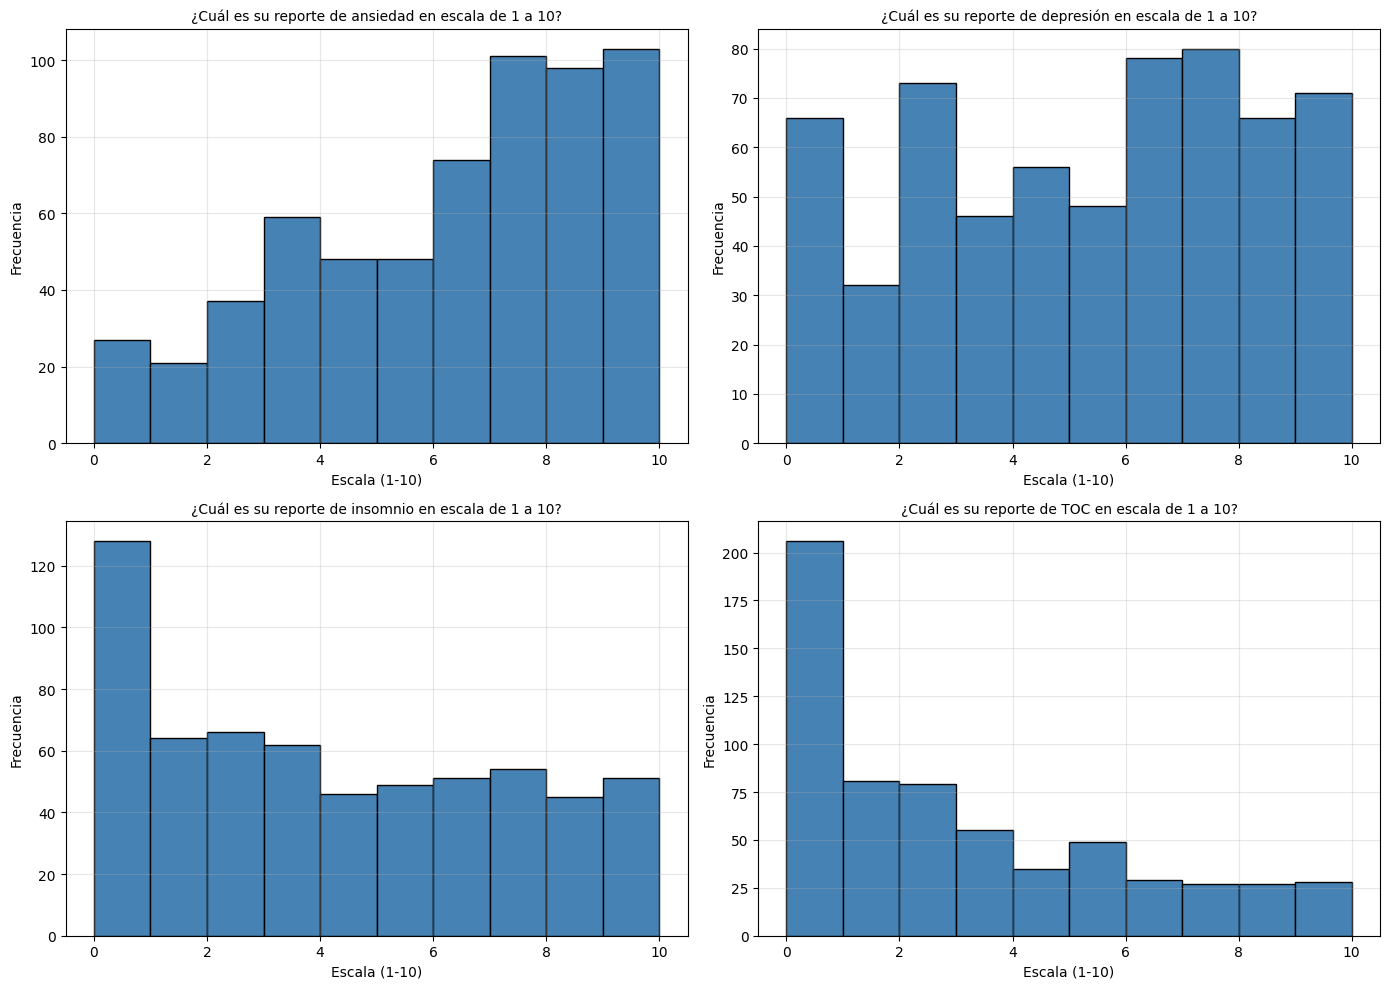

In [ ]:
# Distribución de respuestas para cada indicador de salud mental
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

indicadores = [
    '¿Cuál es su reporte de ansiedad en escala de 1 a 10?',
    '¿Cuál es su reporte de depresión en escala de 1 a 10?',
    '¿Cuál es su reporte de insomnio en escala de 1 a 10?',
    '¿Cuál es su reporte de TOC en escala de 1 a 10?'
]

for idx, (ax, indicador) in enumerate(zip(axes.flat, indicadores)):
    df[indicador].hist(bins=10, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(indicador, fontsize=10)
    ax.set_xlabel('Escala (1-10)')
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#Si tuviéramos que agrupar el comportamiento de este dataset:

#Ansiedad: Concentrada en niveles altos.

#Depresión: Moderada-alta, pero distribuida.

#Insomnio: Mayoría en nivel cero, resto uniforme.

#TOC: Concentrado casi en su totalidad en niveles muy bajos.

In [ ]:
# Muestra las primeras 10 filas del DataFrame limpio (sin nulos, con datos procesados)
df.head(10)

,Fecha y hora,Edad,App utilizada,Horas de escucha por día,¿Escucha música mientras trabaja?,¿Toca algún instrumento?,¿Compone música?,¿Cuál es su género favorito de música?,¿Le gusta explorar nuevos artistas/géneros?,¿Escucha música en lenguajes que usted no habla?,Beats por minuto de su género musical favorito,¿Qué tan seguido escucha música clasica?,¿Qué tan seguido escucha country?,¿Qué tan seguido escucha electrónica?,¿Qué tan seguido escucha folk?,¿Qué tan seguido escucha gospel?,¿Qué tan seguido escucha hip-hop?,¿Qué tan seguido escucha jazz?,¿Qué tan seguido escucha k-pop?,¿Qué tan seguido escucha múica latina?,¿Qué tan seguido escucha lo-fi?,¿Qué tan seguido escucha metal?,¿Qué tan seguido escucha pop?,¿Qué tan seguido escucha r&b?,¿Qué tan seguido escucha rap?,¿Qué tan seguido escucha rock?,¿Qué tan seguido escucha música de videojuegos?,¿Cuál es su reporte de ansiedad en escala de 1 a 10?,¿Cuál es su reporte de depresión en escala de 1 a 10?,¿Cuál es su reporte de insomnio en escala de 1 a 10?,¿Cuál es su reporte de TOC en escala de 1 a 10?,¿Cuál es el efecto que produce la música en sus condiciones de salud mental?,Permiso para publicar la data
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,132.0,Never,Never,Very frequently,Never,Never,Rarely,Rarely,Very frequently,Never,Sometimes,Sometimes,Rarely,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,84.0,Sometimes,Never,Never,Rarely,Sometimes,Never,Very frequently,Sometimes,Very frequently,Sometimes,Never,Sometimes,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,107.0,Never,Never,Rarely,Never,Rarely,Very frequently,Never,Very frequently,Sometimes,Sometimes,Never,Sometimes,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
5,8/27/2022 21:56:50,18.0,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,86.0,Rarely,Sometimes,Never,Never,Never,Sometimes,Very frequently,Very frequently,Rarely,Very frequently,Rarely,Very frequently,Very frequently,Very frequently,Very frequently,Never,8.0,8.0,7.0,7.0,Improve,I understand.
6,8/27/2022 22:00:29,18.0,YouTube Music,3.0,Yes,Yes,No,Video game music,Yes,Yes,66.0,Sometimes,Never,Rarely,Sometimes,Rarely,Rarely,Sometimes,Never,Rarely,Rarely,Rarely,Rarely,Rarely,Never,Never,Sometimes,4.0,8.0,6.0,0.0,Improve,I understand.
7,8/27/2022 22:18:59,21.0,Spotify,1.0,Yes,No,No,K pop,Yes,Yes,95.0,Never,Never,Rarely,Never,Never,Very frequently,Rarely,Very frequently,Never,Sometimes,Never,Sometimes,Sometimes,Rarely,Never,Rarely,5.0,3.0,5.0,3.0,Improve,I understand.
8,8/27/2022 22:33:05,19.0,Spotify,6.0,Yes,No,No,Rock,No,No,94.0,Never,Very frequently,Never,Sometimes,Never,Never,Never,Never,Never,Never,Very frequently,Never,Never,Never,Very frequently,Never,2.0,0.0,0.0,0.0,Improve,I understand.
9,8/27/2022 22:44:03,18.0,I do not use a streaming service.,1.0,Yes,No,No,R&B,Yes,Yes,155.0,Rarely,Rarely,Rarely,Rarely,Sometimes,Rarely,Rarely,Never,Rarely,Rarely,Never,Sometimes,Sometimes,Rarely,Sometimes,Sometimes,2.0,2.0,5.0,1.0,Improve,I understand.
11,8/27/2022 23:00:32,19.0,YouTube Music,8.0,Yes,No,No,EDM,Yes,No,125.0,Rarely,Never,Very frequently,Never,Never,Sometimes,Rarely,Rarely,Rarely,Rarely,Never,Rarely,Rarely,Sometimes,Rarely,Rarely,1.0,0.0,0.0,1.0,Improve,I understand.
13,8/27/2022 23:12:03,19.0,Spotify,2.0,Yes,No,No,Country,Yes,No,88.0,Never,Very frequently,Rarely,Sometimes,Never,Sometimes,Never,Never,Never,Rarely,Never,Rarely,Never,Very frequently,Never,Never,2.0,1.0,2.0,0.0,Improve,I understand.


In [ ]:
# Información del dataframe
print(f"Forma del dataset: {df.shape}")
print(f"Total de filas: {df.shape[0]}")
print(f"Total de columnas: {df.shape[1]}")
print("\nColumnas disponibles:")
print(df.columns.tolist())

Forma del dataset: (616, 33)
Total de filas: 616
Total de columnas: 33

Columnas disponibles:
['Fecha y hora', 'Edad', 'App utilizada', 'Horas de escucha por día', '¿Escucha música mientras trabaja?', '¿Toca algún instrumento?', '¿Compone música?', '¿Cuál es su género favorito de música?', '¿Le gusta explorar nuevos artistas/géneros?', '¿Escucha música en lenguajes que usted no habla?', 'Beats por minuto de su género musical favorito', '¿Qué tan seguido escucha música clasica?', '¿Qué tan seguido escucha country?', '¿Qué tan seguido escucha electrónica?', '¿Qué tan seguido escucha folk?', '¿Qué tan seguido escucha gospel?', '¿Qué tan seguido escucha hip-hop?', '¿Qué tan seguido escucha jazz?', '¿Qué tan seguido escucha k-pop?', '¿Qué tan seguido escucha múica latina?', '¿Qué tan seguido escucha lo-fi?', '¿Qué tan seguido escucha metal?', '¿Qué tan seguido escucha pop?', '¿Qué tan seguido escucha r&b?', '¿Qué tan seguido escucha rap?', '¿Qué tan seguido escucha rock?', '¿Qué tan seguido

In [ ]:
# Resumen estadístico del efecto de la música en la salud mental
print("Efecto de la música en condiciones de salud mental:")
efecto_counts = df['¿Cuál es el efecto que produce la música en sus condiciones de salud mental?'].value_counts()
print(efecto_counts)
print(f"\nTotal de respuestas: {efecto_counts.sum()}")

Efecto de la música en condiciones de salud mental:
¿Cuál es el efecto que produce la música en sus condiciones de salud mental?
Improve      465
No effect    136
Worsen        15
Name: count, dtype: int64

Total de respuestas: 616


C:\Users\aleja\AppData\Local\Temp\ipykernel_16612\3686953427.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='¿Cuál es el efecto que produce la música en sus condiciones de salud mental?',
C:\Users\aleja\AppData\Local\Temp\ipykernel_16612\3686953427.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='¿Cuál es el efecto que produce la música en sus condiciones de salud mental?',
C:\Users\aleja\AppData\Local\Temp\ipykernel_16612\3686953427.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='¿Cuál es el efecto que produce la músi

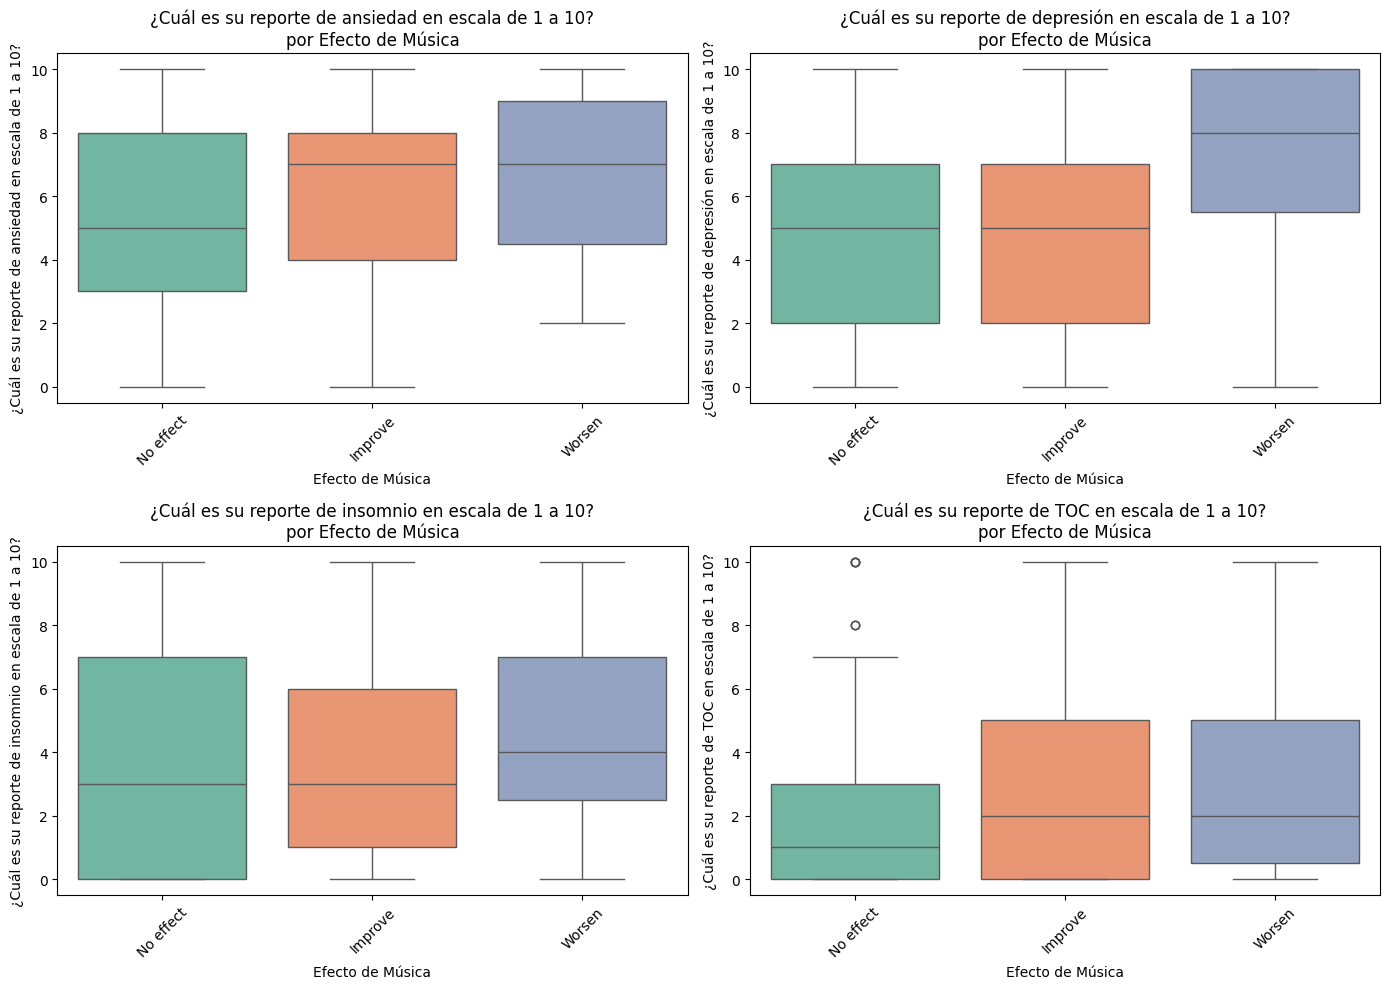

In [ ]:
# Comparación de indicadores de salud mental por efecto de música
efecto_unico = df['¿Cuál es el efecto que produce la música en sus condiciones de salud mental?'].unique()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
indicadores = [
    '¿Cuál es su reporte de ansiedad en escala de 1 a 10?',
    '¿Cuál es su reporte de depresión en escala de 1 a 10?',
    '¿Cuál es su reporte de insomnio en escala de 1 a 10?',
    '¿Cuál es su reporte de TOC en escala de 1 a 10?'
]

for ax, indicador in zip(axes.flat, indicadores):
    sns.boxplot(x='¿Cuál es el efecto que produce la música en sus condiciones de salud mental?', 
                y=indicador, 
                data=df, ax=ax, palette='Set2')
    ax.set_title(f'{indicador}\npor Efecto de Música')
    ax.set_xlabel('Efecto de Música')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Este gráfico de dispersión confirma visualmente lo que ya nos adelantaba la matriz de correlación que vimos al principio: 
# los Beats por Minuto (BPM) de la música tienen una correlación cercana a cero con la salud mental. 
# El tempo o velocidad de las canciones que prefiere la gente no parece ser un factor determinante en sus reportes de ansiedad, depresión, insomnio o TOC.

In [ ]:
# Impacto del efecto de música en indicadores de salud mental
print("\nComparación de Indicadores de Salud Mental por Efecto de Música:\n")

efecto_grupos = df.groupby('¿Cuál es el efecto que produce la música en sus condiciones de salud mental?')[[
    '¿Cuál es su reporte de ansiedad en escala de 1 a 10?',
    '¿Cuál es su reporte de depresión en escala de 1 a 10?',
    '¿Cuál es su reporte de insomnio en escala de 1 a 10?',
    '¿Cuál es su reporte de TOC en escala de 1 a 10?'
]].mean()

print(efecto_grupos)
print("\nBase: Efecto de música en condiciones de salud mental")
print("Valores representan los promedios en escala de 1 a 10")


Comparación de Indicadores de Salud Mental por Efecto de Música:

                                                    ¿Cuál es su reporte de ansiedad en escala de 1 a 10?  \
¿Cuál es el efecto que produce la música en sus...                                                         
Improve                                                                                      6.127957      
No effect                                                                                    4.963235      
Worsen                                                                                       6.666667      

                                                    ¿Cuál es su reporte de depresión en escala de 1 a 10?  \
¿Cuál es el efecto que produce la música en sus...                                                          
Improve                                                                                      4.950538       
No effect                                                        

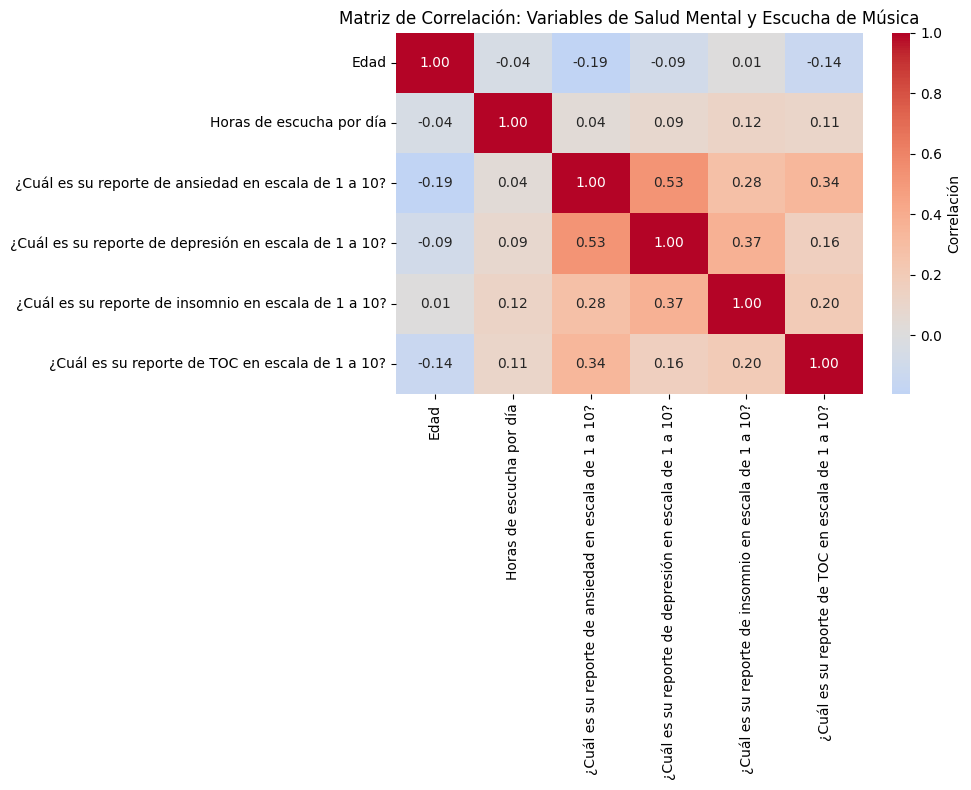

In [ ]:
# Matriz de correlación para variables numéricas de salud mental
vars_salud_mental = [
    'Edad',
    'Horas de escucha por día',
    '¿Cuál es su reporte de ansiedad en escala de 1 a 10?',
    '¿Cuál es su reporte de depresión en escala de 1 a 10?',
    '¿Cuál es su reporte de insomnio en escala de 1 a 10?',
    '¿Cuál es su reporte de TOC en escala de 1 a 10?'
]

plt.figure(figsize=(10, 8))
corr_matrix = df[vars_salud_mental].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Correlación'})
plt.title('Matriz de Correlación: Variables de Salud Mental y Escucha de Música')
plt.tight_layout()
plt.show()

#La fuerte relación entre Ansiedad y Depresión (0.53): Sigue siendo el cruce con color naranja más intenso fuera de la diagonal. Nos confirma que en este dataset, 
# quienes reportan alta ansiedad tienden a reportar niveles altos de depresión de forma simultánea.

#Las "Horas de escucha por día" no se relacionan con la salud mental: Si miras esa fila o columna,
# los valores con los reportes de ansiedad (0.04), depresión (0.09), insomnio (0.12) y TOC (0.11) son muy cercanos a cero 
# (colores grisáceos/arena). Consumir más o menos horas de música al día no parece estar vinculado linealmente con la intensidad de estos síntomas.

#El Insomnio y su vínculo moderado: Muestra una relación positiva moderada con la depresión (0.37) y la ansiedad (0.28), 
# sugiriendo que las dificultades para dormir suelen coexistir con mayores niveles de malestar emocional.

#La Edad y su sutil efecto inverso: Muestra coeficientes negativos con la ansiedad (-0.19) y el TOC (-0.14), 
# indicando que en esta muestra las puntuaciones de estos dos trastornos tienden a disminuir levemente a mayor edad.

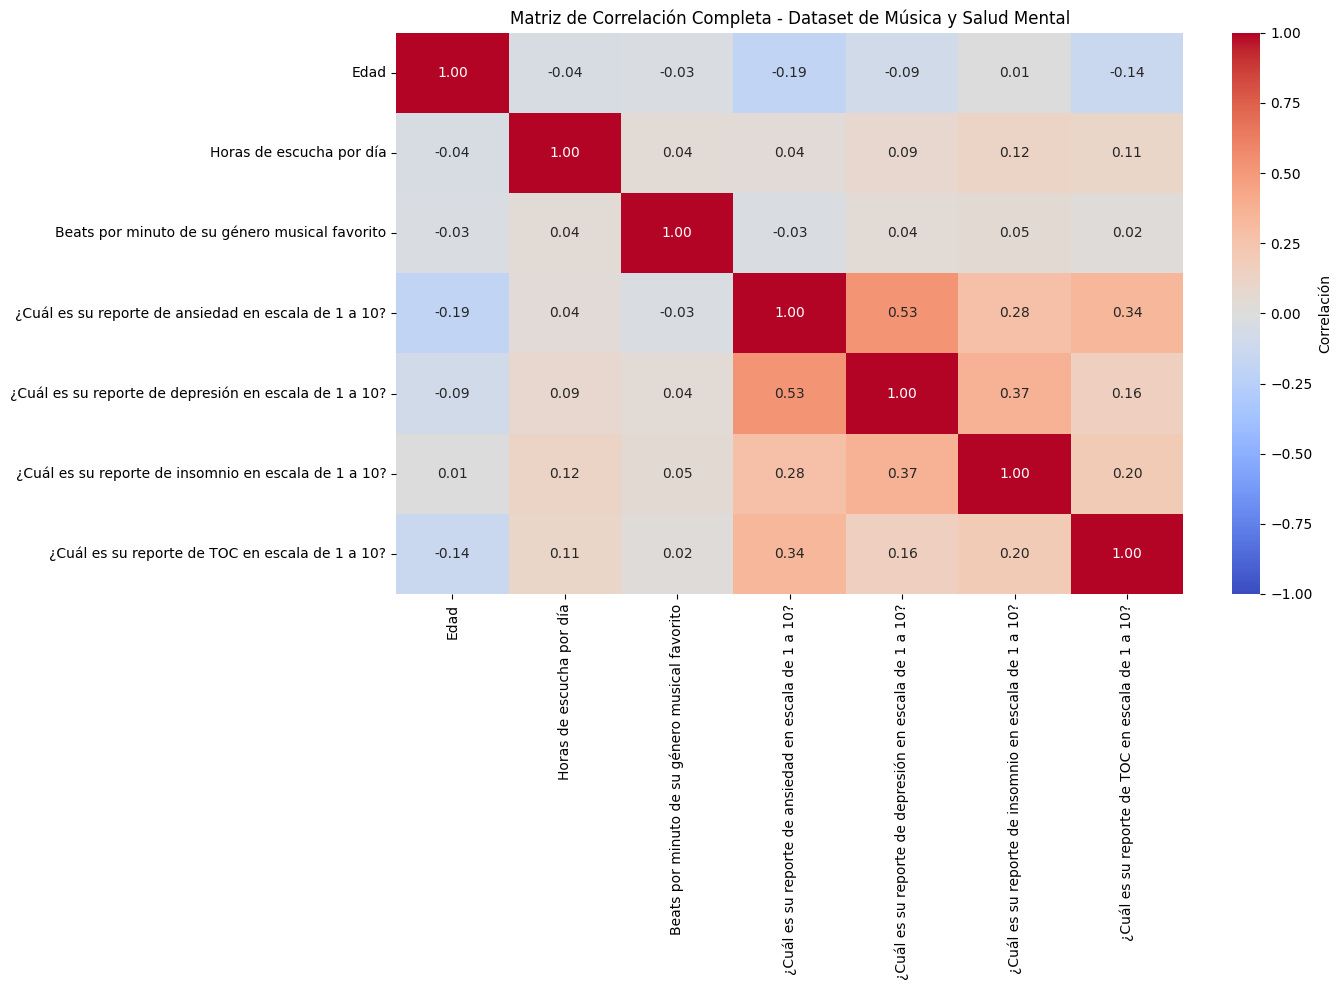

In [ ]:
# Análisis detallado: Heatmap de todas las correlaciones numéricas
plt.figure(figsize=(14, 10))

# Seleccionar solo columnas numéricas existentes
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

if len(numeric_cols) > 1:
    corr_matrix_full = df[numeric_cols].corr()
    sns.heatmap(corr_matrix_full, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Correlación'})
    plt.title('Matriz de Correlación Completa - Dataset de Música y Salud Mental')
    plt.tight_layout()
    plt.show()
else:
    print("Insuficientes columnas numéricas para crear la matriz de correlación.")

In [ ]:
# Resumen final del análisis de música y salud mental
print("=" * 60)
print("RESUMEN DESCRIPTIVO DEL DATASET")
print("=" * 60)
print(f"\nTotal de registros: {len(df)}")
print(f"\nEdad:")
print(f"  Rango: {df['Edad'].min()} - {df['Edad'].max()} años")
print(f"  Promedio: {df['Edad'].mean():.2f} años")
print(f"\nHoras de escucha diaria:")
print(f"  Promedio: {df['Horas de escucha por día'].mean():.2f} horas")
print(f"  Máximo: {df['Horas de escucha por día'].max():.2f} horas")
print(f"\nIndicadores de salud mental (escala 1-10):")
print(f"  Ansiedad promedio: {df['¿Cuál es su reporte de ansiedad en escala de 1 a 10?'].mean():.2f}")
print(f"  Depresión promedio: {df['¿Cuál es su reporte de depresión en escala de 1 a 10?'].mean():.2f}")
print(f"  Insomnio promedio: {df['¿Cuál es su reporte de insomnio en escala de 1 a 10?'].mean():.2f}")
print(f"  TOC promedio: {df['¿Cuál es su reporte de TOC en escala de 1 a 10?'].mean():.2f}")
print("=" * 60)

RESUMEN DESCRIPTIVO DEL DATASET

Total de registros: 616

Edad:
  Rango: 10.0 - 89.0 años
  Promedio: 24.79 años

Horas de escucha diaria:
  Promedio: 3.70 horas
  Máximo: 24.00 horas

Indicadores de salud mental (escala 1-10):
  Ansiedad promedio: 5.88
  Depresión promedio: 4.89
  Insomnio promedio: 3.80
  TOC promedio: 2.66


In [ ]:
# Análisis adicional: Preguntas binarias sobre hábitos musicales
print("\nRespuestas a Preguntas sobre Hábitos Musicales:\n")

preguntas_binarias = [
    '¿Escucha música mientras trabaja?',
    '¿Toca algún instrumento?',
    '¿Compone música?',
    '¿Le gusta explorar nuevos artistas/géneros?',
    '¿Escucha música en lenguajes que usted no habla?'
]

for pregunta in preguntas_binarias:
    if pregunta in df.columns:
        counts = df[pregunta].value_counts()
        print(f"{pregunta}:")
        print(counts)
        print()


Respuestas a Preguntas sobre Hábitos Musicales:

¿Escucha música mientras trabaja?:
¿Escucha música mientras trabaja?
Yes    490
No     126
Name: count, dtype: int64

¿Toca algún instrumento?:
¿Toca algún instrumento?
No     416
Yes    200
Name: count, dtype: int64

¿Compone música?:
¿Compone música?
No     508
Yes    108
Name: count, dtype: int64

¿Le gusta explorar nuevos artistas/géneros?:
¿Le gusta explorar nuevos artistas/géneros?
Yes    451
No     165
Name: count, dtype: int64

¿Escucha música en lenguajes que usted no habla?:
¿Escucha música en lenguajes que usted no habla?
Yes    347
No     269
Name: count, dtype: int64



In [ ]:
# Conclusiones: Resumen de hallazgos principales
print("\n" + "="*70)
print("CONCLUSIONES PRINCIPALES DEL ANÁLISIS")
print("="*70)

# Correlaciones clave
corr_edad_horas = df['Edad'].corr(df['Horas de escucha por día'])
corr_ansiedad_insomnio = df['¿Cuál es su reporte de ansiedad en escala de 1 a 10?'].corr(
    df['¿Cuál es su reporte de insomnio en escala de 1 a 10?']
)

print(f"\n1. Correlación Edad-Horas de escucha: {corr_edad_horas:.4f}")
print(f"   Interpretación: Los indicadores son {'positivamente' if corr_edad_horas > 0 else 'negativamente'} correlacionados")

print(f"\n2. Correlación Ansiedad-Insomnio: {corr_ansiedad_insomnio:.4f}")
print(f"   Interpretación: Los indicadores son {'fuertemente' if abs(corr_ansiedad_insomnio) > 0.7 else 'moderadamente'} correlacionados")

print(f"\n3. Género musical más popular: {df['¿Cuál es su género favorito de música?'].mode()[0]}")

print(f"\n4. App más utilizada: {df['App utilizada'].mode()[0]}")

print("\n" + "="*70)


CONCLUSIONES PRINCIPALES DEL ANÁLISIS

1. Correlación Edad-Horas de escucha: -0.0449
   Interpretación: Los indicadores son negativamente correlacionados

2. Correlación Ansiedad-Insomnio: 0.2750
   Interpretación: Los indicadores son moderadamente correlacionados

3. Género musical más popular: Rock

4. App más utilizada: Spotify



In [ ]:
#¿Por qué escoger un Árbol de Decisión?
#Existen varias razones estratégicas y técnicas para preferir este modelo sobre otros
#Alta Interpretabilidad: Es su mayor ventaja. 
#El razonamiento del árbol es totalmente transparente y comprensible para humanos

#Generación de Reglas de Negocio: Permite extraer reglas claras que el negocio puede implementar de inmediato 

#Versatilidad (Modelos CART): Los árboles tipo CART (Classification and Regression Trees) 
# tienen la capacidad de trabajar tanto en problemas de clasificación (categorías discretas) como de regresión (valores continuos)

#Métricas de Calidad: Proporcionan datos valiosos como la probabilidad de acierto y el soporte
#  (número de casos que respaldan la regla), lo que da seguridad en la toma de decisiones

#Casos donde sirve más que otros tipos de modelos
#El árbol de decisión es la herramienta ideal en los siguientes escenarios:
#Cuando se requiere explicar el "por qué": 
# En sectores donde no basta con una predicción; se necesita justificar legal o técnicamente por qué se tomó una decisión

#Detección de relaciones no lineales: A diferencia de la regresión lineal, 
# que asume que los datos siguen una línea recta, los árboles pueden capturar relaciones mucho más complejas y segmentadas entre variables

#Variables de diferentes tipos: Manejan bien mezclas de variables numéricas y 
# categóricas sin requerir procesos de normalización tan estrictos como otros algoritmos


#Problemas de Clasificación ad hoc: Son excelentes para asignar individuos a clases específicas
#  basadas en condiciones previas, superando en claridad


Beats por Minuto (BPM) por Género Musical Favorito:

                                                mean  count
¿Cuál es su género favorito de música?                     
Video game music                        2.777790e+07     36
EDM                                     1.475000e+02     36
Metal                                   1.396753e+02     77
K pop                                   1.289048e+02     21
Rap                                     1.271000e+02     20
Jazz                                    1.244737e+02     19
Rock                                    1.240336e+02    149
Latin                                   1.225000e+02      2
Pop                                     1.189072e+02     97
Classical                               1.148158e+02     38
Lofi                                    1.143000e+02     10
R&B                                     1.141667e+02     30
Hip hop                                 1.119062e+02     32
Country                                 1.1145

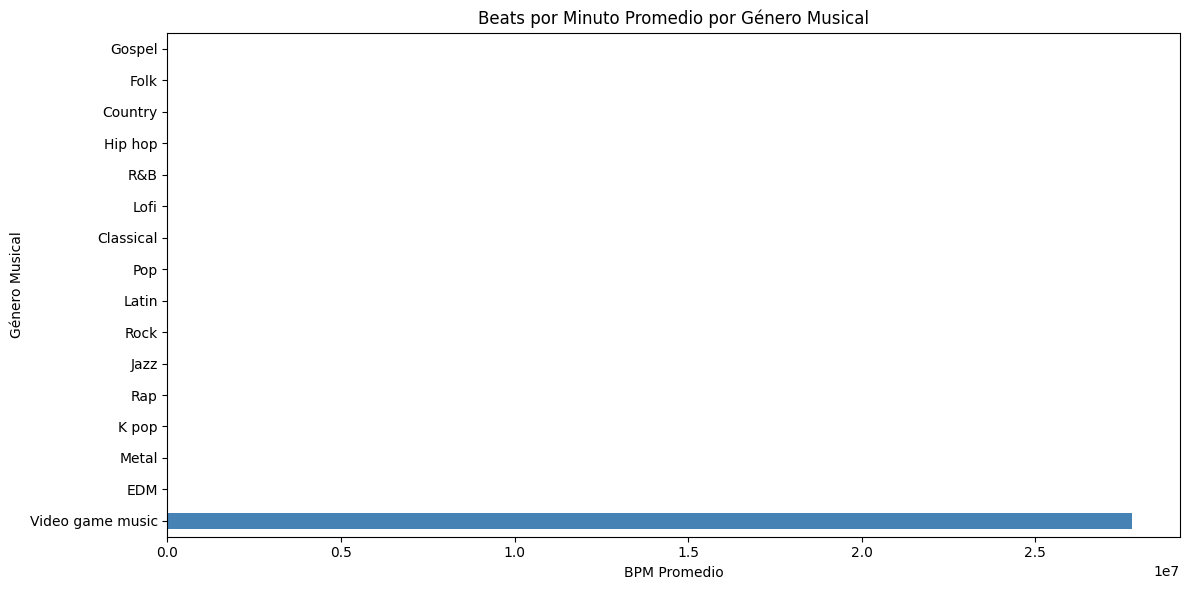

In [ ]:
# Visualización de Beats por Minuto (BPM) por género musical
print("\nBeats por Minuto (BPM) por Género Musical Favorito:\n")

bpm_por_genero = df.groupby('¿Cuál es su género favorito de música?')['Beats por minuto de su género musical favorito'].agg(['mean', 'count'])
bpm_por_genero = bpm_por_genero[bpm_por_genero['count'] > 0].sort_values('mean', ascending=False)

print(bpm_por_genero)

# Gráfico
plt.figure(figsize=(12, 6))
bpm_por_genero['mean'].plot(kind='barh', color='steelblue')
plt.xlabel('BPM Promedio')
plt.ylabel('Género Musical')
plt.title('Beats por Minuto Promedio por Género Musical')
plt.tight_layout()
plt.show()

In [1]:
# Función de entropía 
def entropy(data):
    classes = np.unique(data)
    entropies = []
    for c in classes:
        p = sum(data == c) / len(data)
        current_entropy = p * np.log2(p)
        entropies.append(current_entropy)
    return -1 * sum(entropies)



In [2]:
print("Entropy de género favorito:", entropy(df['¿Cuál es su género favorito de música?'].values))
#Extrae todos los géneros musicales favoritos y calcula su entropía (cuánta variedad hay en total de géneros que escuchan).



NameError: name 'df' is not defined

In [ ]:
high_bpm_favorite = df.loc[
    df['Beats por minuto de su género musical favorito'] >= 175,
    '¿Cuál es su género favorito de música?'
].values
print("Entropy de género favorito con BPM >= 175:", entropy(high_bpm_favorite))
#Filtra los géneros musicales de personas que escuchan música con BPM ≥ 175, y calcula la entropía (diversidad) de esos géneros.

Entropy de género favorito con BPM >= 175: 2.678197737412215


In [ ]:
# Mide la variedad (entropía) de géneros musicales en personas que escuchan a menos de 175 BPM
entropy(df['¿Cuál es su género favorito de música?'][df['Beats por minuto de su género musical favorito'] < 175].values)

np.float64(3.472734494388791)

In [ ]:
# Calcula la entropía ponderada dividiendo los datos en dos grupos según un umbral (threshold).
def weighted_entropy(data, feature, label, threshold):
    indices = data[feature] >= threshold
    entropy_0 = entropy(data[label][indices])
    entropy_1 = entropy(data[label][~indices])
    return entropy_0 * (sum(indices) / len(indices)) + entropy_1 * (sum(~indices) / len(indices))

In [ ]:
# Aplica la función para calcular la entropía ponderada de los géneros musicales, dividiendo a los encuestados según si escuchan a más o menos de 175 BPM.
weighted_entropy(df, 'Beats por minuto de su género musical favorito', '¿Cuál es su género favorito de música?', 175)

np.float64(3.4172717012881533)

In [ ]:
# Calcula la Ganancia de Información
# Resta la entropía ponderada (después de dividir por BPM) a la entropía original total.
entropy(df['¿Cuál es su género favorito de música?'].values) - weighted_entropy(df, 'Beats por minuto de su género musical favorito', '¿Cuál es su género favorito de música?', 175)
#te dice qué tanta "incertidumbre" o desorden te quitas de encima al separar a las personas según si escuchan música a más o menos de 175 BPM.

np.float64(0.03393873473142728)

In [ ]:
# Prueba 100 valores distintos de BPM para calcular y guardar la Ganancia de Información de cada uno.
bpm_information_gain_sweep = []
bpm_thresholds = np.linspace(df['Beats por minuto de su género musical favorito'].min(), df['Beats por minuto de su género musical favorito'].max(), 100)

for threshold in bpm_thresholds:
    bpm_information_gain_sweep.append(
        entropy(df['¿Cuál es su género favorito de música?'].values) - 
        weighted_entropy(df, 'Beats por minuto de su género musical favorito', '¿Cuál es su género favorito de música?', threshold)
    )

In [ ]:
bpm_min = df['Beats por minuto de su género musical favorito'].min()
bpm_max = df['Beats por minuto de su género musical favorito'].max()

bpm_thresholds = np.linspace(bpm_min, bpm_max, 100)

#Ganancia de Información para encontrar el mejor 
# umbral  de BPM para un árbol de decisión.

NameError: name 'df' is not defined

In [ ]:
# Prueba 100 valores distintos de Edad para calcular y guardar la Ganancia de Información de cada uno.
edad_information_gain_sweep = []
edad_thresholds = np.linspace(df['Edad'].min(), df['Edad'].max(), 100)

for threshold in edad_thresholds:
    edad_information_gain_sweep.append(
        entropy(df['¿Cuál es su género favorito de música?'].values) - 
        weighted_entropy(df, 'Edad', '¿Cuál es su género favorito de música?', threshold)
    )

<Axes: >

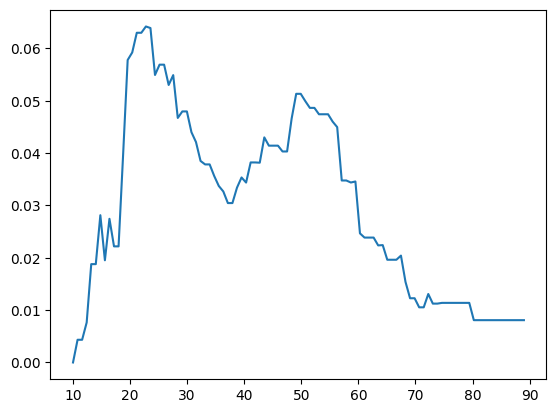

In [ ]:
# Grafica la Ganancia de Información para cada edad. 
# El punto más alto indicará la mejor edad para dividir los datos y predecir el género musical.
sns.lineplot(
    x = edad_thresholds,
    y = edad_information_gain_sweep
)




#A nivel técnico, este gráfico demuestra que la Edad es una variable infinitamente mejor que los BPM para alimentar tu árbol de decisión.
#  Mientras que los BPM te daban una ganancia casi nula y plana, la Edad ofrece picos claros de diferenciación (especialmente a los 23-24 años y a los 50 años), 
# lo que le permite al algoritmo trazar fronteras lógicas para clasificar las preferencias musicales.

Text(0.5, 0, 'Umbral')

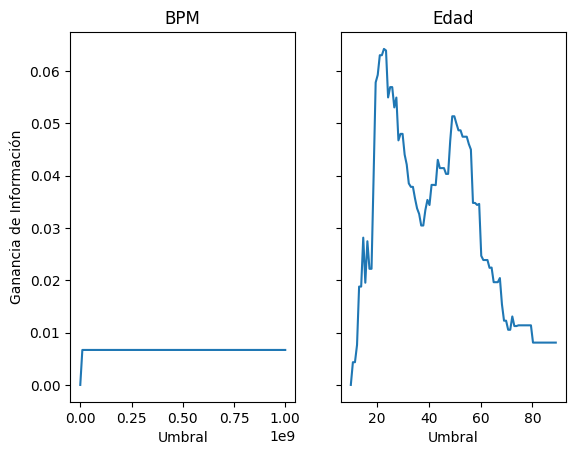

In [ ]:
# Crea una figura con dos gráficos secundarios juntos para comparar visualmente 
# la Ganancia de Información de los BPM (izquierda) y de la Edad (derecha). en este caso el de edad es el más optimo para seguir analizando el árbol de decisión
fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True)

sns.lineplot(
    x = bpm_thresholds,
    y = bpm_information_gain_sweep,
    ax = axs[0]
)

sns.lineplot(
    x = edad_thresholds,
    y = edad_information_gain_sweep,
    ax = axs[1]
)

axs[0].set_title("BPM")
axs[1].set_title("Edad")
axs[0].set_ylabel("Ganancia de Información")
axs[0].set_xlabel("Umbral")
axs[1].set_xlabel("Umbral")

In [ ]:
# Encuentra el valor exacto de BPM que proporciona la mayor Ganancia de Información.
optimal_bpm_threshold = bpm_thresholds[np.argmax(bpm_information_gain_sweep)]
optimal_bpm_threshold

np.float64(10101010.090909092)

In [ ]:
# Calcula la entropía para el grupo con BPM mayor o igual al óptimo
high_bpm_optimal = df.loc[
    df['Beats por minuto de su género musical favorito'] >= optimal_bpm_threshold, 
    '¿Cuál es su género favorito de música?'
].values

entropy(high_bpm_optimal)

np.float64(-0.0)

In [ ]:
# Calcula la entropía para el grupo con BPM menor al óptimo
low_bpm_optimal = df.loc[
    df['Beats por minuto de su género musical favorito'] < optimal_bpm_threshold, 
    '¿Cuál es su género favorito de música?'
].values

entropy(low_bpm_optimal)

np.float64(3.4501296148263614)

In [ ]:
# Importamos la herramienta necesaria de scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Crea un árbol de decisión muy simple (un solo nivel de profundidad) basado en la entropía, 
# y lo entrena usando los BPM y la Edad para intentar predecir el género musical favorito.
single_decision = DecisionTreeClassifier(max_depth=1, criterion="entropy")
single_decision = single_decision.fit(
    df[["Beats por minuto de su género musical favorito", "Edad"]], 
    df["¿Cuál es su género favorito de música?"]
)

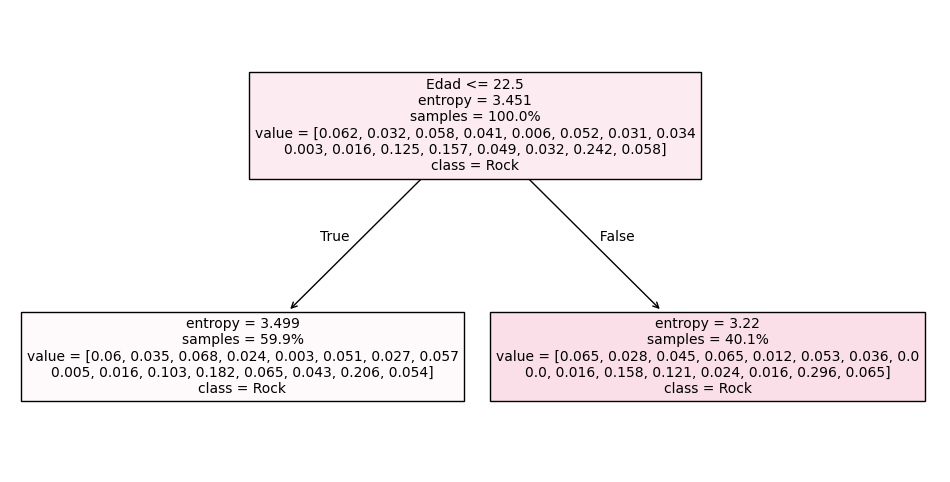

In [ ]:
import sklearn.tree

# Ajustamos el tamaño de la figura para que se vea bien (opcional pero recomendado)
plt.figure(figsize=(12, 6)) 

sklearn.tree.plot_tree( # Función que nos permite visualizar el árbol de decisión ajustado.
    single_decision, # Objeto de nuestro árbol de decisión entrenado.
    feature_names = ["Beats por minuto de su género musical favorito", "Edad"], # Nombres de las variables utilizadas para entrenar.
    class_names = single_decision.classes_.tolist(), # Extrae automáticamente los géneros musicales del modelo.
    label = "all", # Etiquetamos todas las características de cada nodo.
    proportion = True, # Visualizamos las proporciones de datos en cada nodo de decisión.
    filled = True, # Coloreamos los nodos.
    fontsize = 10 # Establecemos el tamaño de la letra del texto dentro de cada nodo.
)

plt.show()

#Edad <= 22.5: 
# El algoritmo descubrió de forma autónoma que el mejor corte inicial para separar los datos es alrededor de los 22 o 23 años.

#entropy = 3.451: La entropía mide el desorden o la mezcla de los datos. 
# Como hay muchos géneros musicales diferentes mezclados en este punto, 
# el desorden es alto (3.451). El objetivo del árbol es bajar este número en los siguientes pasos.

#samples = 100.0%: Como es la raíz, aquí está el 100% de los datos de tus encuestados.

#value =Es una lista que muestra la proporción de personas que prefieren cada género musical 
# (hay 16 valores en total, correspondientes a las 16 clases/géneros del dataset).

#class = Rock: Es la predicción por defecto en este nodo. Significa que, 
# si el árbol tuviera que adivinar a ciegas en este instante sin preguntar nada más, diría "Rock" porque es el género mayoritario en esa lista de proporciones.



#Rama de la izquierda (True): Por aquí viajan todas las personas que cumplen la condición, es decir, que tienen 22 años o menos.

#Rama de la derecha (False): Por aquí viajan todas las personas que no la cumplen, es decir, los mayores de 22.5 años.

#Aquí vemos cómo cambiaron los grupos después de pasar por el filtro de la edad:

#samples = 59.9%: El grupo joven representa casi el 60% de tu dataset.

#entropy = 3.499: Curiosamente, la entropía subió un poquito aquí. Esto significa que dentro del grupo joven, 
# la variedad de gustos musicales sigue siendo extremadamente caótica y mezclada.

#class = Rock: El Rock sigue siendo el género dominante para los menores de 22.5 años en esta muestra.

#samples = 40.1%: Los mayores de 22.5 años representan el 40.1% restante de los datos.

#entropy = 3.22: Aquí la entropía bajó (de 3.451 a 3.22).
# Esto indica que al separar a los mayores de 22.5 años, los datos se volvieron un poco más "puros" u organizados; 
# es decir, ciertos géneros musicales empezaron a concentrarse más claramente en este rango de edad.

#class = Rock: A pesar de que la distribución interna de los porcentajes cambió en el arreglo value (puedes ver que el penúlt valor subió a 0.296, ganando mucho peso), 
# el Rock sigue manteniéndose como la clasificación mayoritaria en este nodo.

In [ ]:
# Separamos el dataset en dos partes: 
# 1. Las características (todas las columnas excepto la que queremos predecir)
# 2. La etiqueta (la columna que queremos predecir: el género musical)

df_features = df.drop(columns=['¿Cuál es su género favorito de música?'])
df_label = df['¿Cuál es su género favorito de música?']

In [ ]:
from sklearn.model_selection import train_test_split

# Divide los datos en dos grupos: uno para entrenar el modelo (67%) y otro para probarlo (33%).
(
    df_features_train,
    df_features_test,
    df_label_train,
    df_label_test
) = train_test_split(
    df_features,
    df_label,
    test_size=0.33,
    random_state=11
)

In [ ]:
tree = sklearn.tree.DecisionTreeClassifier( # Instanciamos nuestro árbol de decisión.
    max_depth=3, # Forzamos que nuestro árbol solo tenga 3 niveles de profundidad.
    criterion = "entropy"
)
tree.fit( # Ajustamos nuestro árbol de decisión.
    df_features_train,
    df_label_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
# Genera un reporte detallado comparando las respuestas reales con las predicciones del modelo.
print(sklearn.metrics.classification_report(
    df_label_test,
    tree.predict(df_features_test)
))

                  precision    recall  f1-score   support

       Classical       0.06      0.06      0.06        16
         Country       0.00      0.00      0.00        12
             EDM       0.00      0.00      0.00         9
            Folk       0.00      0.00      0.00        12
          Gospel       0.00      0.00      0.00         1
         Hip hop       0.00      0.00      0.00        11
            Jazz       0.00      0.00      0.00         7
           K pop       0.00      0.00      0.00         6
            Lofi       0.00      0.00      0.00         4
           Metal       0.20      0.32      0.25        28
             Pop       0.22      0.29      0.25        21
             R&B       0.00      0.00      0.00        10
             Rap       0.00      0.00      0.00         7
            Rock       0.28      0.61      0.38        51
Video game music       0.00      0.00      0.00         9

        accuracy                           0.23       204
       macro

c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

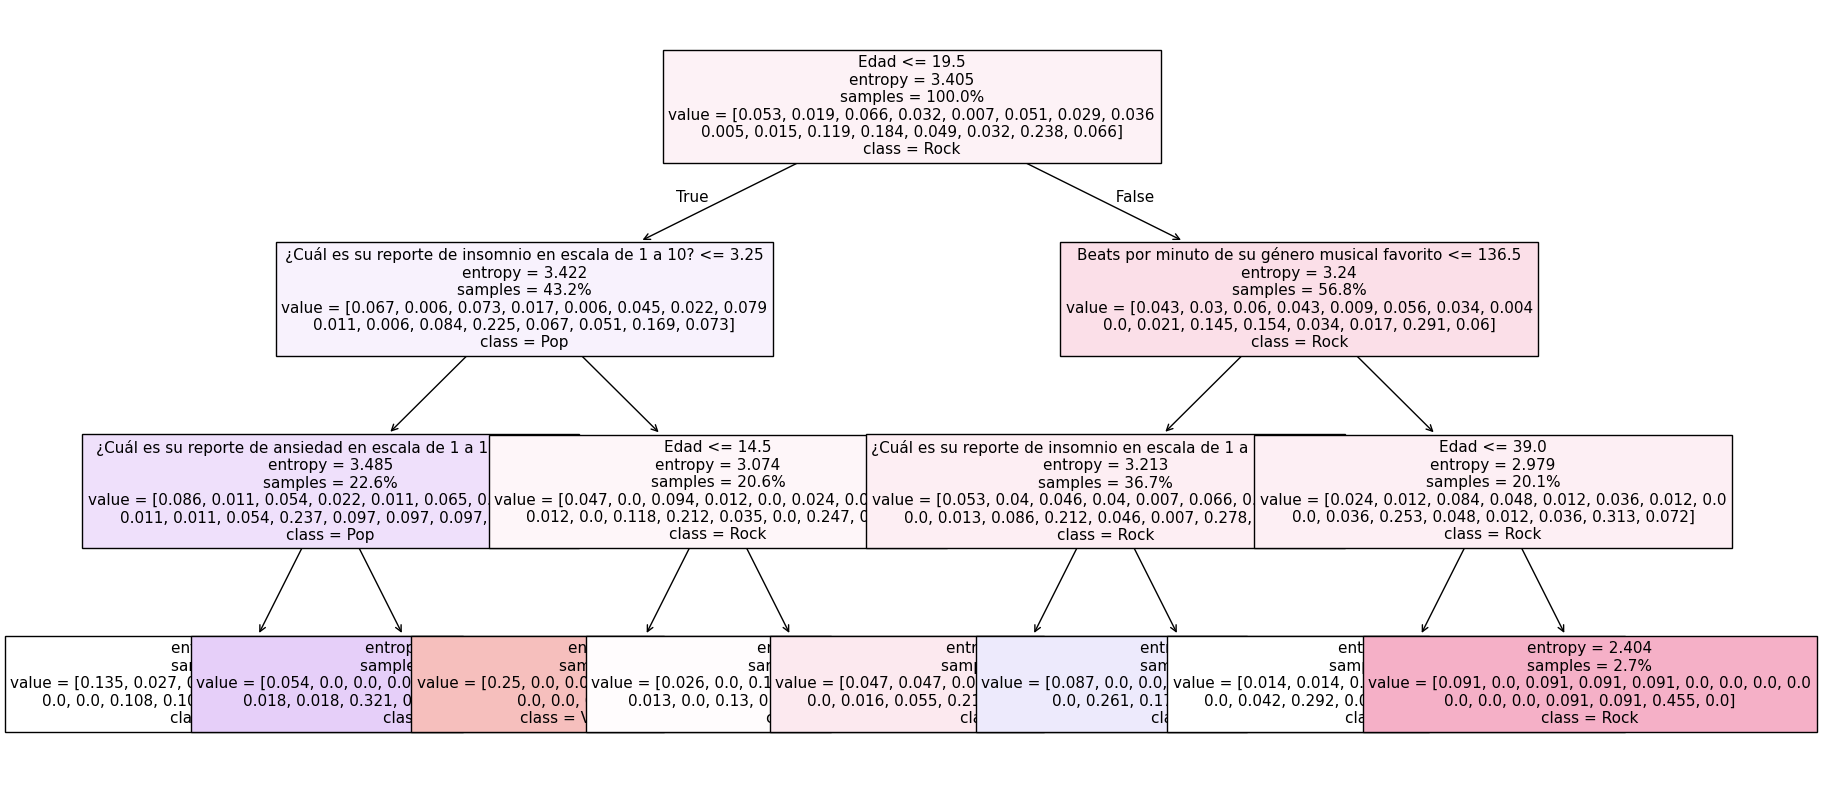

In [ ]:
plt.figure(figsize=(20, 10))

sklearn.tree.plot_tree( # Función que nos permite visualizar el árbol de decisión ajustado.
    tree, # Objeto de nuestro árbol de decisión entrenado.
    feature_names = df_features.columns, # Nombres de las variables utilizadas para entrenar.
    class_names = tree.classes_.tolist(), # Nombre de las clases que estamos prediciendo (extraídas automáticamente).
    label = "all", # Etiquetamos todas las características de cada nodo.
    proportion = True, # Visualizamos las proporciones de datos en cada nodo de decisión.
    filled = True, # Coloreamos los nodos.
    fontsize = 11 # Establecemos el tamaño de la letra del texto dentro de cada nodo.
)

plt.show()

In [ ]:
depths = range(1, 10)
performances = []

for depth in depths:
    current_tree = sklearn.tree.DecisionTreeClassifier(
        max_depth=depth,
        criterion="entropy",
        random_state=11 # Mantenemos fijos los resultados internos
    )
    
    # 1. Cambiamos scoring a "accuracy" (adecuado para múltiples clases)
    # 2. Agregamos cv=3 para manejar clases con muy pocos registros
    score = sklearn.model_selection.cross_val_score(
          current_tree,
          df_features,
          df_label,
          scoring="accuracy", 
          cv=3 
      ).mean()
    
    performances.append(score)

print("¡Barrido completado con éxito! Valores guardados en 'performances'.")

c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


¡Barrido completado con éxito! Valores guardados en 'performances'.


c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
c:\Users\aleja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.

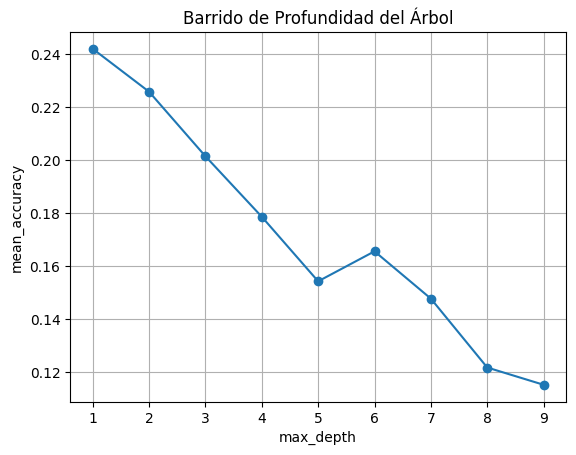

In [ ]:
# Grafica el barrido de profundidades contra el rendimiento obtenido
plt.plot(depths, performances, marker="o")

plt.xlabel("max_depth")
plt.ylabel("mean_accuracy")
plt.title("Barrido de Profundidad del Árbol")
plt.grid(True)

plt.show()

#Una precisión máxima del 24% (0.24) nos indica que predecir el género musical favorito basándose únicamente en variables como la Edad o los BPM es
#una tarea muy difícil para el algoritmo. La música es sumamente subjetiva y es probable que necesites más datos o variables diferentes 
#(como el país, el estado de ánimo o el instrumento favorito) para que un modelo matemático logre superar ese techo.